<a href="https://colab.research.google.com/github/SumaiyaZohaRODELA/Image-search-with-captioning/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install torch torchvision transformers faiss-cpu pillow matplotlib

In [3]:
import os
import torch
import faiss
import numpy as np
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [5]:
from google.colab import drive
import os
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV file
csv_path = "/content/drive/My Drive/animal.csv"

# Check if file exists
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"✅ Loaded 'animal.csv'")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)}")
    print("\n--- First 5 rows ---")
    print(df.head())
else:
    print(f"❌ File not found at: {csv_path}")
    print("\nListing contents of My Drive:")
    for f in os.listdir("/content/drive/My Drive"):
        print(f"  - {f}")

Mounted at /content/drive
✅ Loaded 'animal.csv'
   Shape: (696, 2)
   Columns: ['image_path', 'product_name']

--- First 5 rows ---
                 image_path product_name
0   cat_image/images/10.jpg        বিড়াল
1  cat_image/images/100.jpg        বিড়াল
2  cat_image/images/101.jpg        বিড়াল
3  cat_image/images/102.jpg        বিড়াল
4  cat_image/images/103.jpg        বিড়াল


In [6]:
image_paths = [os.path.join("/content/drive/My Drive", path) for path in df['image_path'].tolist()]
print(f"Found {len(image_paths)} image paths with full paths.")

Found 696 image paths with full paths.


In [7]:
image_embeddings = []

for path in image_paths:
    # Construct the full path explicitly, assuming 'path' might still be relative
    full_image_path = os.path.join("/content/drive/My Drive", path)
    image = Image.open(full_image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.get_image_features(**inputs)

    # Access the pooler_output from the BaseModelOutputWithPooling object
    embedding = output.pooler_output.cpu().numpy()

    # Normalize
    embedding = embedding / np.linalg.norm(embedding)

    image_embeddings.append(embedding)

image_embeddings = np.vstack(image_embeddings)

In [8]:
dimension = image_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(image_embeddings)

print("Total images indexed:", index.ntotal)

Total images indexed: 696


In [9]:
query = "A scary cat"

inputs = processor(text=query, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.get_text_features(**inputs)

text_embedding = output.pooler_output.cpu().numpy()

# Normalize
text_embedding = text_embedding / np.linalg.norm(text_embedding)

In [10]:
top_k = 3

scores, indices = index.search(text_embedding, top_k)

print("Top matches:")

Top matches:


Attempting to display image 1 (index 677) from path: /content/drive/My Drive/cat_image/images/82.jpg
  Image properties: Size=(5819, 4364), Format=None, Mode=RGB
Successfully processed and attempted to display image.

Attempting to display image 2 (index 372) from path: /content/drive/My Drive/cat_image/images/437.jpg
  Image properties: Size=(3024, 4032), Format=None, Mode=RGB
Successfully processed and attempted to display image.

Attempting to display image 3 (index 538) from path: /content/drive/My Drive/cat_image/images/587.jpg
  Image properties: Size=(3960, 2640), Format=None, Mode=RGB
Successfully processed and attempted to display image.



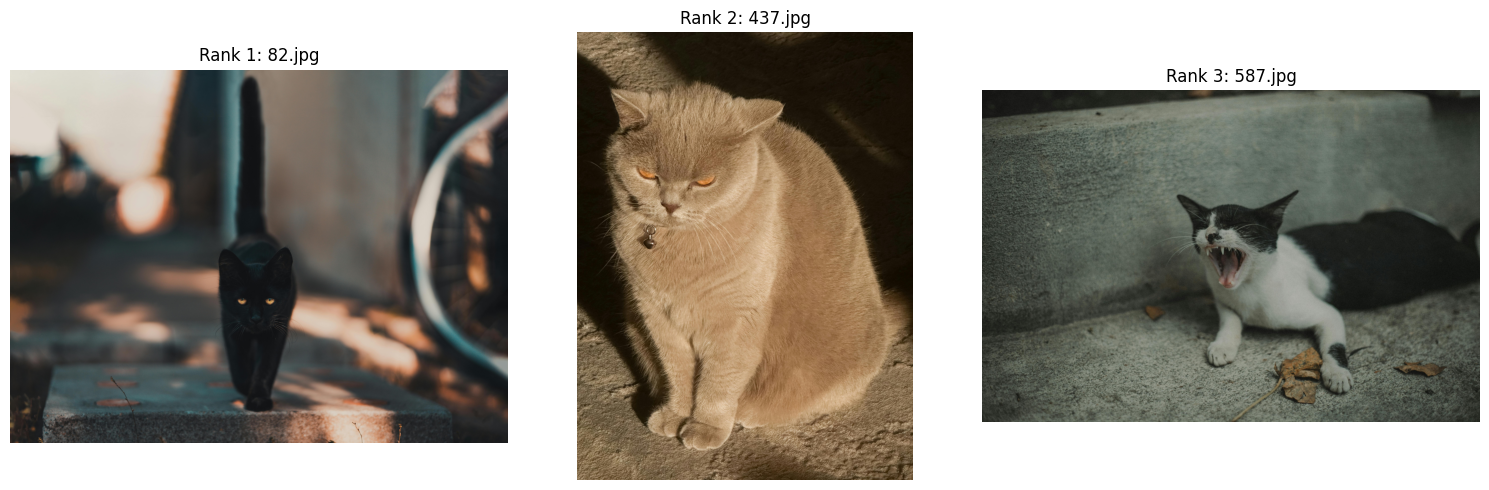

In [11]:
fig, axes = plt.subplots(1, top_k, figsize=(15, 5))
axes = axes.flatten() # Ensure axes is iterable even if top_k is 1

for i, idx in enumerate(indices[0]):
    image_path = image_paths[idx]

    print(f"Attempting to display image {i+1} (index {idx}) from path: {image_path}")

    if not os.path.exists(image_path):
        print(f"ERROR: Image file not found at: {image_path}. Skipping this image.\n")
        axes[i].set_title(f"Rank {i+1}: Not Found")
        axes[i].axis("off")
        continue

    try:
        img = Image.open(image_path).convert("RGB")
        # Print metadata to confirm image loading
        print(f"  Image properties: Size={img.size}, Format={img.format}, Mode={img.mode}")

        axes[i].imshow(img)
        axes[i].set_title(f"Rank {i+1}: {os.path.basename(image_path)}")
        axes[i].axis("off")
        print("Successfully processed and attempted to display image.\n")
    except Exception as e:
        print(f"ERROR: Could not open or display image {image_path}: {e}. Skipping this image.\n")
        axes[i].set_title(f"Rank {i+1}: Error")
        axes[i].axis("off")

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

.

 .

.

### Integrate LLM for Image Captioning

This section demonstrates how to use a Large Language Model (LLM) to generate descriptive captions for images. These captions can then be used for more advanced filtering, re-ranking, or even as a source for ground truth in evaluating your CLIP model's performance.

In [ ]:
pip install google-generativeai

To use the Gemini API, you'll need an API key. If you don't already have one, create a key in Google AI Studio.
In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GOOGLE_API_KEY`. Then pass the key to the SDK:

In [ ]:
#!pip install google-genai